In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import *

In [11]:
df = pd.read_csv('Concrete_Data.csv')
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [12]:
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [14]:
df.columns.tolist()


['Cement (component 1)(kg in a m^3 mixture)',
 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
 'Fly Ash (component 3)(kg in a m^3 mixture)',
 'Water  (component 4)(kg in a m^3 mixture)',
 'Superplasticizer (component 5)(kg in a m^3 mixture)',
 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
 'Fine Aggregate (component 7)(kg in a m^3 mixture)',
 'Age (day)',
 'Concrete compressive strength(MPa, megapascals) ']

In [15]:
X = df.drop("Concrete compressive strength(MPa, megapascals) ", axis=1)
y = df["Concrete compressive strength(MPa, megapascals) "]


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4️⃣ Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [41]:
model = KNeighborsRegressor(n_neighbors=5)  
model.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
y_pred = model.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"MAPE: {mape:.2f}")

MAE: 6.89
MSE: 74.91
R² Score: 0.71
MAPE: 0.24


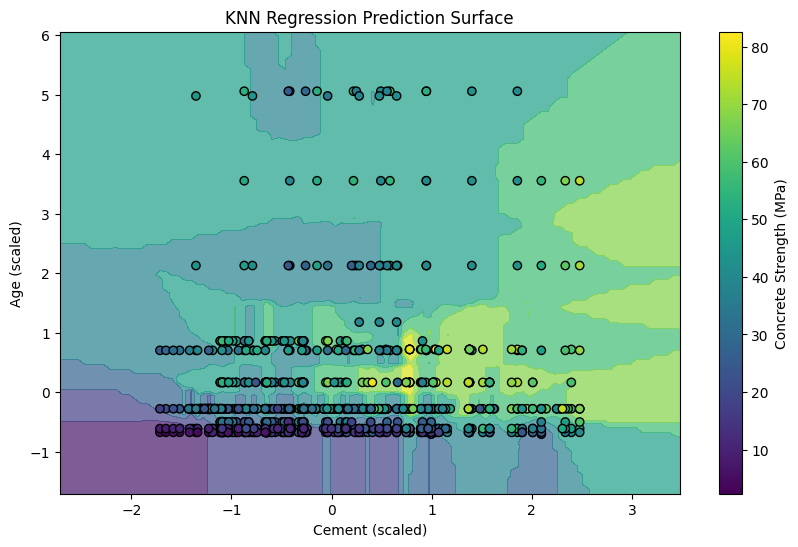

In [ ]:
X_vis = X_scaled[:, [0, 7]]  # first column (Cement) and last column (Age)
y_vis = y.values

# Train KNN regressor on 2 features
knn_vis = KNeighborsRegressor(n_neighbors=5)
knn_vis.fit(X_vis, y_vis)

# Create a grid to plot predictions
x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict on the grid
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.7)
plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, edgecolor='k', cmap='viridis')
plt.xlabel("Cement (scaled)")
plt.ylabel("Age (scaled)")
plt.title("KNN Regression Prediction Surface")
plt.colorbar(label="Concrete Strength (MPa)")
plt.show()

Predicted Concrete Strength: 7.9159999999999995


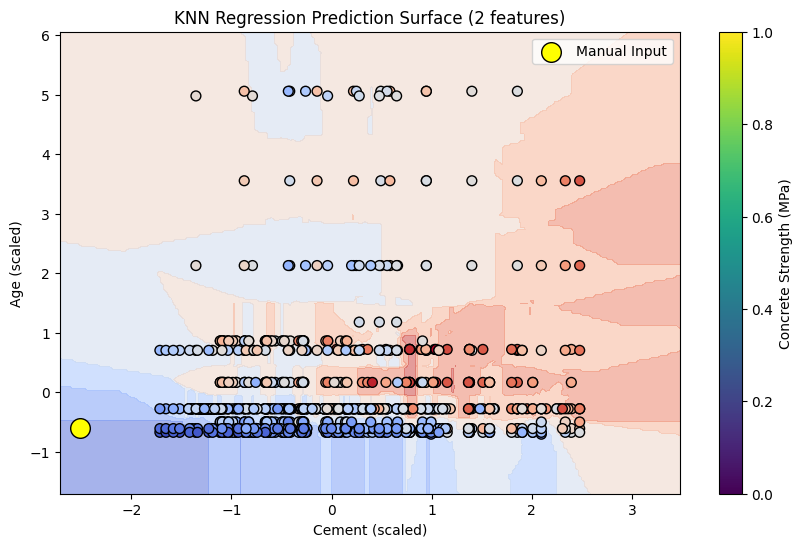

In [48]:
X_vis = X.iloc[:, [0, 7]].values  # Cement, Age
y_vis = y.values

scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

knn_vis = KNeighborsRegressor(n_neighbors=5)
knn_vis.fit(X_vis_scaled, y_vis)

manual_point = np.array([[19, 8]])  # Cement=19, Age=8
manual_point_scaled = scaler_vis.transform(manual_point)
predicted_value = knn_vis.predict(manual_point_scaled)
print("Predicted Concrete Strength:", predicted_value[0])

x1_min, x1_max = X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1
x2_min, x2_max = X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))

Z = knn_vis.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx1, xx2, Z, cmap='coolwarm', alpha=0.5)
plt.scatter(X_vis_scaled[:,0], X_vis_scaled[:,1], c=y_vis, edgecolor='k', cmap='coolwarm', s=50)
plt.scatter(manual_point_scaled[0,0], manual_point_scaled[0,1], color='yellow', edgecolor='black', s=200, label='Manual Input')
plt.xlabel("Cement (scaled)")
plt.ylabel("Age (scaled)")
plt.title("KNN Regression Prediction Surface (2 features)")
plt.colorbar(label="Concrete Strength (MPa)")
plt.legend()
plt.show()